# Making predictions with a multiple regression model

In [2]:
import pandas as pd
import seaborn as sns

## The Cars dataset
- We are looking at the large dataset

In [3]:
carsData = pd.read_csv('../data/cars.csv')

In [4]:
carsData.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


## Summary
- 205 rows
- 26 columns

In [5]:
carsData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

### Heat Map with the correlations with price (It's all about the engine)
- Strongest correlation is engine size, and negative is MPG (higher the MPG, the lower the price)

<Axes: >

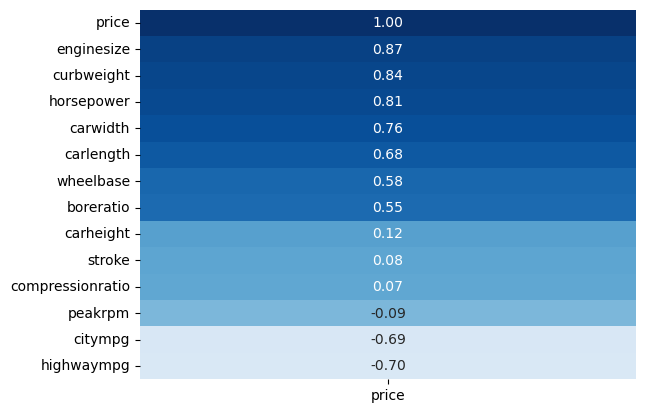

In [6]:
numeric_cols = ["wheelbase","carlength","carwidth","carheight","curbweight","enginesize","boreratio","stroke","compressionratio","horsepower","peakrpm","citympg","highwaympg","price"]
sns.heatmap(data=carsData[numeric_cols].corr()[["price"]].sort_values('price', ascending=False), 
            annot=True, cmap='Blues', vmin=-1.0, vmax=1.0, cbar=False, fmt='.2f')

# How to create a simple regression model
- We did this before with the housing data.
- Repeat simple regression with the cars data
- The score in this model is .76

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [8]:
x_train, x_test, y_train, y_test = train_test_split(
    carsData[['enginesize']], carsData[['price']],
    test_size=0.20, random_state=20)

model = LinearRegression()
model.fit(x_train, y_train)

model.score(x_test,y_test)

0.7063964117029844

In [9]:
model.score(x_train, y_train)

0.766524123801206

In [10]:
y_predicted = model.predict(x_test)

### Predictions of the price based on engine size (single variable)
- Lets' look at the top 10 predictions 

In [56]:
# create DataFrame for the price predictions
predicted = pd.DataFrame(y_predicted, columns=['predictedPrice'])

# combine the test data and the predicted data into a frame
final = predicted.join([x_test.reset_index(drop=True), 
                        y_test.reset_index(drop=True)])
final[['enginesize','price','predictedPrice']].head(10)

,enginesize,price,predictedPrice
0,136,15250.0,13517.858822
1,90,8916.5,5968.304606
2,92,8778.0,4984.725918
3,203,31400.5,37778.843127
4,92,6488.0,5347.966676
5,97,13845.0,8926.310250
6,91,6695.0,6135.395101
7,108,11694.0,10312.188132
8,120,15580.0,15397.832249
9,121,15510.0,12590.292979


## How to plot the residuals of a simple regression (How good is the prediction/model?)
- These graphs show if the preduction is good.
- First we look at the residuals.
- But the KDE plot tells a better story.  It needs to look like a bell curve with the center being around zero. 

In [12]:
final['residual'] = final['price'] - final['predictedPrice']
final.head(5)

,predictedPrice,enginesize,price,residual
0,14905.920686,136,15250.0,344.079314
1,7164.387613,90,8916.5,1752.112387
2,7500.976007,92,8778.0,1277.023993
3,26181.631901,203,31400.5,5218.868099
4,7500.976007,92,6488.0,-1012.976007


/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


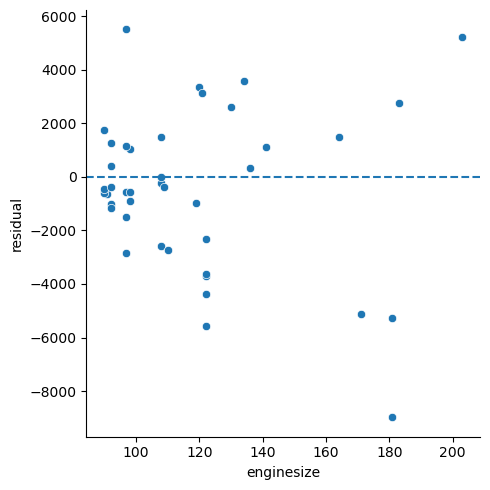

In [13]:
g = sns.relplot(data=final, x='enginesize', y='residual', kind='scatter')
for ax in g.axes.flat:
    ax.axhline(0, ls='--')

### This is bell curve with the center around zero

<Axes: xlabel='residual', ylabel='Density'>

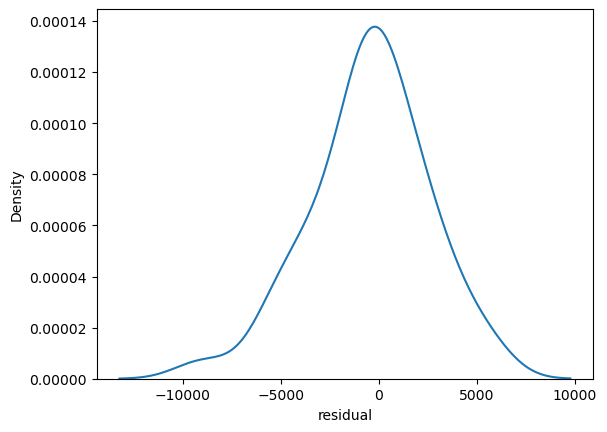

In [14]:
sns.kdeplot(data=final, x='residual')

# How to create a multiple regression model
### A multiple regression model is very similar to a simple regression, but you specify more variables in train_test_split

#### Before
```
train_test_split(
    carsData[['enginesize']], carsData[['price']]
```

#### After
```
train_test_split(
    carsData[['enginesize','curbweight']], carsData[['price']]
```

In [15]:
x_train, x_test, y_train, y_test = train_test_split(
    carsData[['enginesize','curbweight']], carsData[['price']], 
    test_size=0.20, random_state=20)

model = LinearRegression()
model.fit(x_train, y_train)

model.score(x_test, y_test)

0.7581072748679533

### The score is .79 up from .77

In [16]:
model.score(x_train, y_train)

0.7950435284247739

In [17]:
y_predicted = model.predict(x_test)

## How to prepare and plot the multiple regression

### The predictions

In [18]:
# create the DataFrame for the price predictions
predicted = pd.DataFrame(y_predicted, columns=['predictedPrice'])

# combine the test data and the predicted data into a DataFrame
final = predicted.join([x_test.reset_index(drop=True), 
                        y_test.reset_index(drop=True)])
final.head()[['enginesize','curbweight','price','predictedPrice']]

,enginesize,curbweight,price,predictedPrice
0,136,2507,15250.0,14186.974331
1,90,1874,8916.5,5681.243299
2,92,3110,8778.0,12256.116157
3,203,3366,31400.5,26252.387995
4,92,2015,6488.0,6633.723732


## How to plot the residuals of a multiple regression

In [19]:
final['residual'] = final['price'] - final['predictedPrice']
final.head()

,predictedPrice,enginesize,curbweight,price,residual
0,14186.974331,136,2507,15250.0,1063.025669
1,5681.243299,90,1874,8916.5,3235.256701
2,12256.116157,92,3110,8778.0,-3478.116157
3,26252.387995,203,3366,31400.5,5148.112005
4,6633.723732,92,2015,6488.0,-145.723732


<Axes: xlabel='residual', ylabel='Density'>

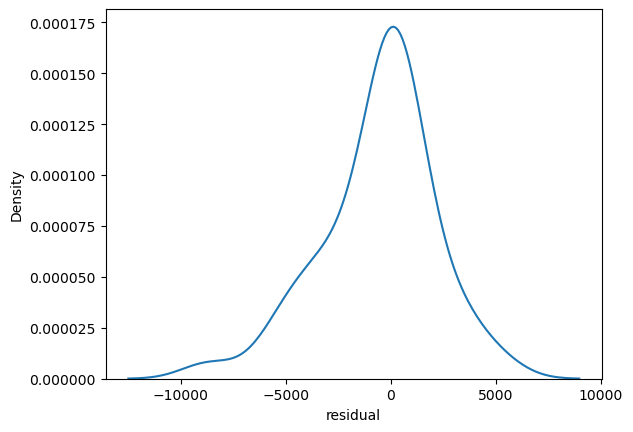

In [20]:
sns.kdeplot(data=final, x='residual')

## How to identify categorical variables
- Not all data is numerical
- We want to look at categorical data
- If we want to use categorical variables as independent variables we must
  1. Identify
  2. Review (should we include them?)
  3. Prepare (create dummy variables)

### Identify
- nominal: Categorical data that can't be ordered in a meaningful way
- ordinal: Categorical data that CAN be ordered in a meaningful way
- dichotomous: Only two categories, yes/no, true/false, etc.
- Categorical data can be stored as strings or integers

In [21]:
carsData.nunique()

car_ID              205
symboling             6
CarName             147
fueltype              2
aspiration            2
doornumber            2
carbody               5
drivewheel            3
enginelocation        2
wheelbase            53
carlength            75
carwidth             44
carheight            49
curbweight          171
enginetype            7
cylindernumber        7
enginesize           44
fuelsystem            8
boreratio            38
stroke               37
compressionratio     32
horsepower           59
peakrpm              23
citympg              29
highwaympg           30
price               189
dtype: int64

## How to review categorical variables
- value_counts(): Lists each unique values and the number of times it occurs
- Look for only two unique values
- Try to choose variables that are well balanced (equal numbers) when choosing independent variables.
- This ensures that when you chose your values for the training data, you have your independent variables well represented

##### Well balanced does not mean that there is a high correlation (R)

### Dichotomous variables (look for 2) 


In [22]:
carsData.enginelocation.value_counts()

enginelocation
front    202
rear       3
Name: count, dtype: int64

In [23]:
carsData.fueltype.value_counts()

fueltype
gas       185
diesel     20
Name: count, dtype: int64

In [24]:
carsData.aspiration.value_counts()

aspiration
std      168
turbo     37
Name: count, dtype: int64

In [25]:
carsData.doornumber.value_counts()

doornumber
four    115
two      90
Name: count, dtype: int64

### Nominal variables

In [26]:
carsData.fuelsystem.value_counts()

fuelsystem
mpfi    94
2bbl    66
idi     20
1bbl    11
spdi     9
4bbl     3
mfi      1
spfi     1
Name: count, dtype: int64

In [27]:
carsData.carbody.value_counts()

carbody
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64

In [28]:
carsData.drivewheel.value_counts()

drivewheel
fwd    120
rwd     76
4wd      9
Name: count, dtype: int64

In [29]:
carsData.enginetype.value_counts()

enginetype
ohc      148
ohcf      15
ohcv      13
dohc      12
l         12
rotor      4
dohcv      1
Name: count, dtype: int64

In [30]:
carsData.cylindernumber.value_counts()

cylindernumber
four      159
six        24
five       11
eight       5
two         4
three       1
twelve      1
Name: count, dtype: int64

## How to create dummy variables
- Dummy variables are used to convert categorical data into a numerical format that the model can understand
- They create binary (0/1) columns for each category level.
- The first category, e.g., "West", is dropped to avoid multi-collinearity, also known as the dummy variable trap.
- The dummy variable trap is a situation in regression analysis where perfect multi-collinearity occurs due to including all dummy variables for a categorical variable.

### You use dummy variables in pandas for regression because:
1. Regression needs numeric input.
2. Dummy variables convert categories into a usable form.
3. The let the model estimate the effects of each category


In [57]:
catColumns = ['aspiration','doornumber','carbody','drivewheel']
dummies = pd.get_dummies(carsData[catColumns])
dummies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   aspiration_std       205 non-null    bool 
 1   aspiration_turbo     205 non-null    bool 
 2   doornumber_four      205 non-null    bool 
 3   doornumber_two       205 non-null    bool 
 4   carbody_convertible  205 non-null    bool 
 5   carbody_hardtop      205 non-null    bool 
 6   carbody_hatchback    205 non-null    bool 
 7   carbody_sedan        205 non-null    bool 
 8   carbody_wagon        205 non-null    bool 
 9   drivewheel_4wd       205 non-null    bool 
 10  drivewheel_fwd       205 non-null    bool 
 11  drivewheel_rwd       205 non-null    bool 
dtypes: bool(12)
memory usage: 2.5 KB


In [32]:
carsDummies = carsData.drop(columns=catColumns)
carsDummies = carsDummies.join(dummies)
carsDummies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_ID               205 non-null    int64  
 1   symboling            205 non-null    int64  
 2   CarName              205 non-null    object 
 3   fueltype             205 non-null    object 
 4   enginelocation       205 non-null    object 
 5   wheelbase            205 non-null    float64
 6   carlength            205 non-null    float64
 7   carwidth             205 non-null    float64
 8   carheight            205 non-null    float64
 9   curbweight           205 non-null    int64  
 10  enginetype           205 non-null    object 
 11  cylindernumber       205 non-null    object 
 12  enginesize           205 non-null    int64  
 13  fuelsystem           205 non-null    object 
 14  boreratio            205 non-null    float64
 15  stroke               205 non-null    flo

## How to rescale the data and check the correlations
### You have to put the dummy variables on the same scale as the rest of the data

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numCols = ['wheelbase','carlength','carwidth','carheight','curbweight',
           'enginesize','boreratio','stroke','compressionratio','horsepower',
           'peakrpm','citympg','highwaympg']
carsDummies[numCols] = scaler.fit_transform(carsDummies[numCols])
carsDummies.head()

,car_ID,symboling,CarName,fueltype,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,...,doornumber_four,doornumber_two,carbody_convertible,carbody_hardtop,carbody_hatchback,carbody_sedan,carbody_wagon,drivewheel_4wd,drivewheel_fwd,drivewheel_rwd
0,1,3,alfa-romero giulia,gas,front,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,...,False,True,True,False,False,False,False,False,False,True
1,2,3,alfa-romero stelvio,gas,front,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,...,False,True,True,False,False,False,False,False,False,True
2,3,1,alfa-romero Quadrifoglio,gas,front,-0.708596,-0.231513,-0.190566,-0.543527,0.514882,...,False,True,False,False,True,False,False,False,False,True
3,4,2,audi 100 ls,gas,front,0.173698,0.207256,0.136542,0.235942,-0.420797,...,True,False,False,False,False,True,False,False,True,False
4,5,2,audi 100ls,gas,front,0.107110,0.207256,0.230001,0.235942,0.516807,...,True,False,False,False,False,True,False,True,False,False


### Check the correlations

In [34]:
numWithPrice = numCols
numWithPrice.append("price")
carsDummies[numWithPrice].corr()[['price']].sort_values(by='price', ascending=False)

,price
price,1.000000
enginesize,0.874145
curbweight,0.835305
horsepower,0.808139
carwidth,0.759325
carlength,0.682920
wheelbase,0.577816
boreratio,0.553173
carheight,0.119336
stroke,0.079443


## How to create a multiple regression that includes dummy variables
1. Split the data into the training set and the test
2. Create the model
3. Score the model with test data
4. Score the model with training data
5. If the test score is worse than the training score, you might want to try different combinations of variables
6. Make predictions 

In [35]:
carsTrain, carsTest = train_test_split(carsDummies, test_size=0.2, 
    random_state=20)

In [36]:
model = LinearRegression()
xCols = ['enginesize','horsepower','carwidth',
         'drivewheel_rwd','highwaympg']
model.fit(carsTrain[xCols], carsTrain['price'])

model.score(carsTest[xCols], carsTest['price'])

0.7523820020019689

In [37]:
model.score(carsTrain[xCols], carsTrain['price'])

0.8334860355280258

In [38]:
y_predicted = model.predict(carsTest[xCols])

In [39]:
predicted = pd.DataFrame(y_predicted, columns=['predictedPrice'])

final = predicted.join([carsTest[xCols].reset_index(drop=True),
                        carsTest['price'].reset_index(drop=True)])

final[['enginesize','horsepower','carwidth','drivewheel_rwd',
       'highwaympg','price','predictedPrice']].head()

,enginesize,horsepower,carwidth,drivewheel_rwd,highwaympg,price,predictedPrice
0,0.218885,0.149133,0.183272,False,-0.837195,15250.0,13517.858822
1,-0.888455,-0.864871,-1.078431,False,1.783034,8916.5,5968.304606
2,-0.840310,-1.067671,-1.078431,False,0.181783,8778.0,4984.725918
3,1.831749,4.661448,2.987056,True,-0.400490,31400.5,37778.843127
4,-0.840310,-1.067671,-1.078431,False,1.055193,6488.0,5347.966676


## How to select the independent variables
### Use a heat map to see the highest correlations between dependent variables (price) and various independent variables. 

<Axes: >

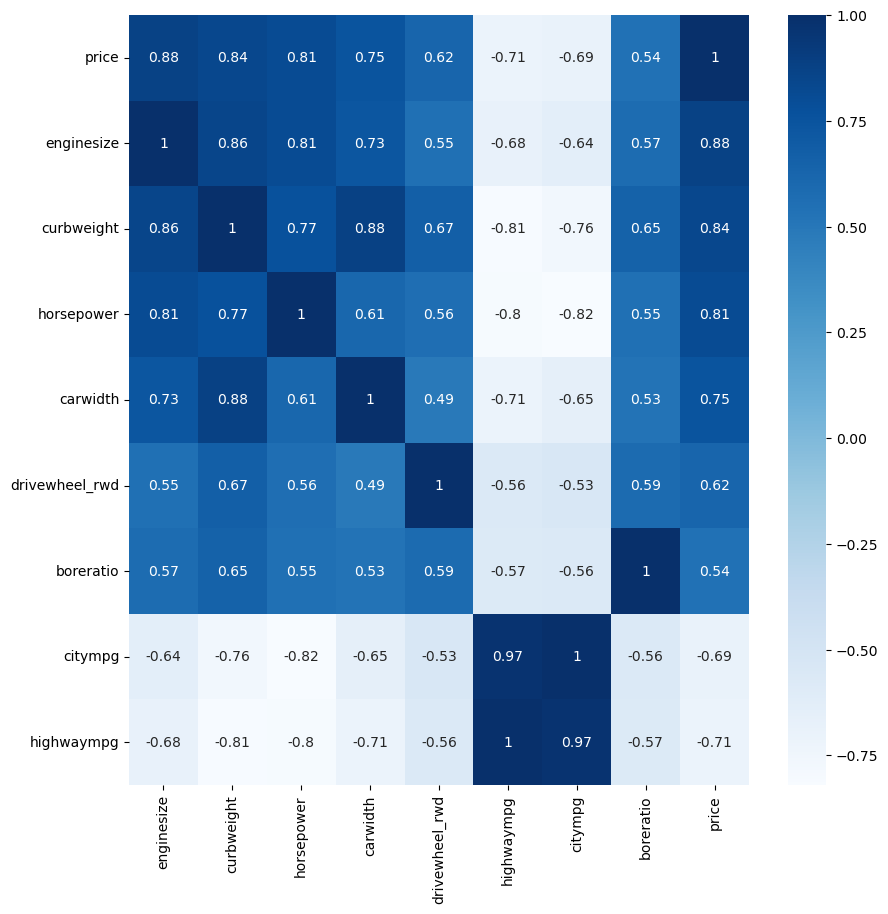

In [40]:
# use Matplotlib to set the size of the plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,10))

# create the heatmap
sns.heatmap(carsTrain[['enginesize','curbweight','horsepower','carwidth',
                              'drivewheel_rwd','highwaympg','citympg','boreratio',
                              'price']].corr().sort_values(by='price', ascending=False), 
            cmap='Blues', annot=True)

## How to test different combinations of variables
### Overfitting:  when you add too many variables but the test score does not improve 

### An initial model that's fitted to eight independent variables

In [41]:
model = LinearRegression()
xCols = ['enginesize','curbweight','horsepower','carwidth', 'carlength',
         'drivewheel_rwd','highwaympg','citympg']
model.fit(carsTrain[xCols], carsTrain['price'])
model.score(carsTest[xCols], carsTest['price'])

0.7392437314293404

In [42]:
model.score(carsTrain[xCols], carsTrain['price'])

0.8344434015448825

### The initial model without the citympg column

In [43]:
model = LinearRegression()
xCols = ['enginesize','curbweight','horsepower','carwidth','carlength',
         'drivewheel_rwd','highwaympg']
model.fit(carsTrain[xCols], carsTrain['price'])
model.score(carsTest[xCols], carsTest['price'])

0.7430944903647658

In [44]:
model.score(carsTrain[xCols], carsTrain['price'])

0.8339017954221501

### A model that's fitted to all the numeric and dummy variables

In [45]:
model = LinearRegression()
xCols = ['wheelbase','carlength','carwidth','carheight','curbweight','enginesize','boreratio','stroke','compressionratio','horsepower','peakrpm','citympg','highwaympg','aspiration_std','aspiration_turbo','doornumber_four','doornumber_two','carbody_convertible','carbody_hardtop','carbody_hatchback','carbody_sedan','carbody_wagon',
 'drivewheel_4wd','drivewheel_fwd','drivewheel_rwd']
model.fit(carsTrain[xCols], carsTrain['price'])
model.score(carsTest[xCols], carsTest['price'])

0.7737122835618835

In [46]:
model.score(carsTrain[xCols], carsTrain['price'])

0.8778455360116013

## How to use SciKit learn to select the variables
### You can use SciKit learn to pick the right variables and the right number of variables

### SelectBest(): Selects the top k features based on the values returned by the scoring function 

In [47]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_regression

In [48]:
carsTrain, carsTest = train_test_split(carsDummies.drop(
    columns=['CarName','fueltype','enginelocation','cylindernumber',
             'fuelsystem','enginetype']), test_size=0.2, random_state=20)

In [49]:
fs = SelectKBest(score_func=mutual_info_regression, k=20)
fs.fit(carsTrain.drop(columns=['price']), carsTrain['price'])

SelectKBest(k=20,
            score_func=<function mutual_info_regression at 0x7d6b3044e7a0>)

In [50]:
x_train_fs = fs.transform(carsTrain.drop(columns=['price']))
x_test_fs = fs.transform(carsTest.drop(columns=['price']))

In [51]:
model = LinearRegression()
model.fit(x_train_fs, carsTrain['price'])
model.score(x_test_fs, carsTest['price'])

0.7730268917681581

In [52]:
model.score(x_train_fs, carsTrain['price'])

0.8826996202377456

### Which features are the most important 
#### Correlation Isn’t Always the Same as Predictive Power
- This happens when a variable has a high correlation with the target, but contains redundant information because another variable already captures it
- We are scoring each independently and not considering colinarity (one can be predicted from the others with high accuracy)

In [53]:
df1 = pd.DataFrame(carsTrain.drop(columns=['price']).columns, columns=['feature'])
df2 = pd.DataFrame(fs.scores_, columns=['importance'])
importance = df1.join(df2)
importance.sort_values('importance', ascending=False).head()

,feature,importance
6,curbweight,0.903258
11,horsepower,0.877233
14,highwaympg,0.863458
7,enginesize,0.854222
13,citympg,0.733272


## How to select the right number of variables
### Correct number of features is 4 for this model
- Try to identify the lowest number of features that delivers the highest training score with the smallest gap between the training and test scores

<Axes: xlabel='numFeatures'>

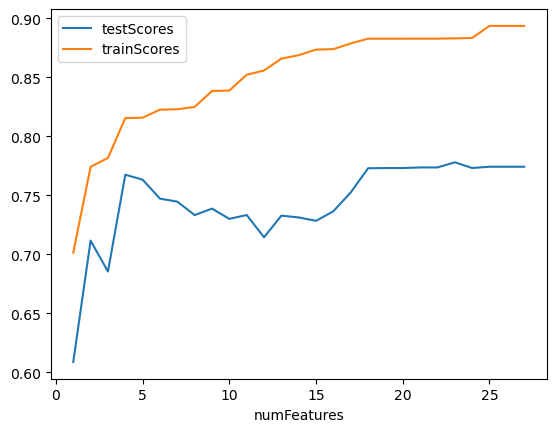

In [54]:
model = LinearRegression()
testScores = []
trainScores = []

for i in range(1, len(carsTrain.columns)):
    fs = SelectKBest(score_func=mutual_info_regression, k=i)
    fs.fit(carsTrain.drop(columns=['price']), carsTrain['price'])

    x_train_fs = fs.transform(carsTrain.drop(columns=['price']))
    x_test_fs = fs.transform(carsTest.drop(columns=['price']))

    model.fit(x_train_fs, carsTrain['price'])
    
    testScore = model.score(x_test_fs, carsTest['price'])
    trainScore = model.score(x_train_fs, carsTrain['price'])
    testScores.append(testScore)
    trainScores.append(trainScore)
    
df = pd.DataFrame(data={'testScores':testScores, 'trainScores':trainScores})
df = df.reset_index()
df = df.rename(columns={'index':'numFeatures'})
df['numFeatures'] = df['numFeatures'] + 1
df.plot(x='numFeatures', y=['testScores','trainScores'])

<Axes: xlabel='numFeatures'>

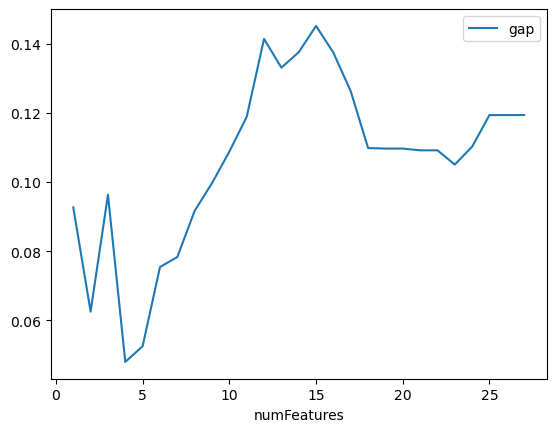

In [55]:
# Or, if you only want to plot the gap, you could do it like this...
df['gap'] = df['trainScores'] - df['testScores']
df.plot(x='numFeatures', y=['gap'])